# Import Packages

In [6]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

print("Import Successful")

Import Successful


# Load Model 

In [7]:
cnn = tf.keras.models.load_model("/kaggle/input/ingredient-detection/keras/v1/1/trained_model.h5")

# Single Image Prediction

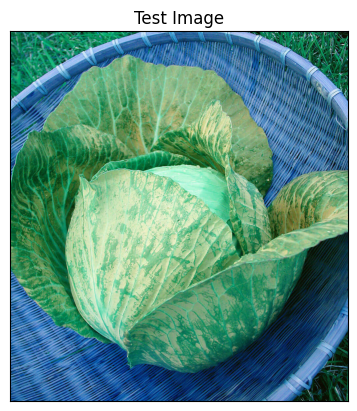

In [32]:
import cv2
image_path = "/kaggle/input/fruit-and-vegetable-image-recognition/test/cabbage/Image_10.jpg"
img = cv2.imread(image_path)
plt.imshow(img)
plt.title("Test Image")
plt.xticks([])
plt.yticks([])
plt.show()


# Model Testing 

In [33]:
# Pre-processing and Loading Image 
image = tf.keras.preprocessing.image.load_img( image_path , target_size = ( 64 , 64 ))
input_arr = tf.keras.preprocessing.image.img_to_array(image)
input_arr = np.expand_dims( input_arr , axis = 0 )
prediction = cnn.predict(input_arr)
print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
[[9.17492102e-13 7.25923390e-13 1.02136368e-20 2.18853032e-07
  9.99279439e-01 1.26277459e-14 9.48504020e-19 1.90012930e-08
  2.42096976e-20 6.24434993e-14 6.72162983e-08 5.28928877e-15
  4.66856481e-15 9.81388636e-15 1.70517165e-13 4.40360508e-12
  3.71724309e-12 1.04042904e-07 7.54899268e-11 7.20074226e-04
  9.09315511e-18 6.87371006e-15 1.75340039e-17 2.00693997e-12
  4.36963833e-11 2.46276415e-13 2.48631720e-27 4.93821564e-15
  1.08950955e-08 1.44022062e-14 5.30876124e-13 4.06864958e-11
  2.13143758e-25 7.77553746e-17 3.32919491e-11 6.66196542e-10]]


In [15]:
# Testing Data Pre-processing

test_set = tf.keras.utils.image_dataset_from_directory(
    '/kaggle/input/fruit-and-vegetable-image-recognition/test',
    labels = 'inferred' ,
    label_mode = 'categorical' ,
    class_names = None ,
    color_mode = 'rgb' ,
    batch_size = 32 ,
    image_size = ( 64 , 64 ) ,
    shuffle = True ,
    seed = None ,
    validation_split = None ,
    subset = None ,
    interpolation = 'bilinear' ,
    follow_links = False ,
    crop_to_aspect_ratio = False
)

Found 359 files belonging to 36 classes.


In [16]:
test_set.class_names

['apple',
 'banana',
 'beetroot',
 'bell pepper',
 'cabbage',
 'capsicum',
 'carrot',
 'cauliflower',
 'chilli pepper',
 'corn',
 'cucumber',
 'eggplant',
 'garlic',
 'ginger',
 'grapes',
 'jalepeno',
 'kiwi',
 'lemon',
 'lettuce',
 'mango',
 'onion',
 'orange',
 'paprika',
 'pear',
 'peas',
 'pineapple',
 'pomegranate',
 'potato',
 'raddish',
 'soy beans',
 'spinach',
 'sweetcorn',
 'sweetpotato',
 'tomato',
 'turnip',
 'watermelon']

In [34]:
result_index = np.where( prediction[0] == max( prediction[0] ) )
print(result_index[0][0])

4


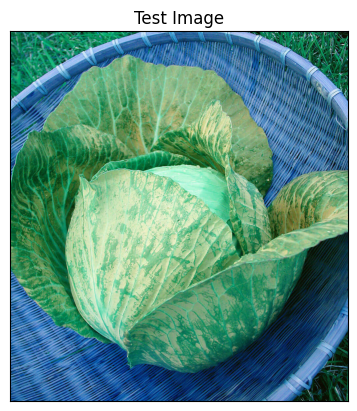

In [35]:
# Display Image
plt.imshow(img)
plt.title("Test Image")
plt.xticks([])
plt.yticks([])
plt.show()

In [36]:
# Single Prediction

print("It's a {}" .format(test_set.class_names[result_index[0][0]]))

It's a cabbage
